# Rendering Charts to File Formats

Render a chart to SVG, PNG, or JPG bytes using `chart.render(fmt)`.

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume
from mplchart.indicators import SMA, RSI, MACD

from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")

In [2]:
prices = sample_prices()
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11325 entries, 1980-12-12 to 2025-11-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    11325 non-null  float64
 1   high    11325 non-null  float64
 2   low     11325 non-null  float64
 3   close   11325 non-null  float64
 4   volume  11325 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 530.9 KB


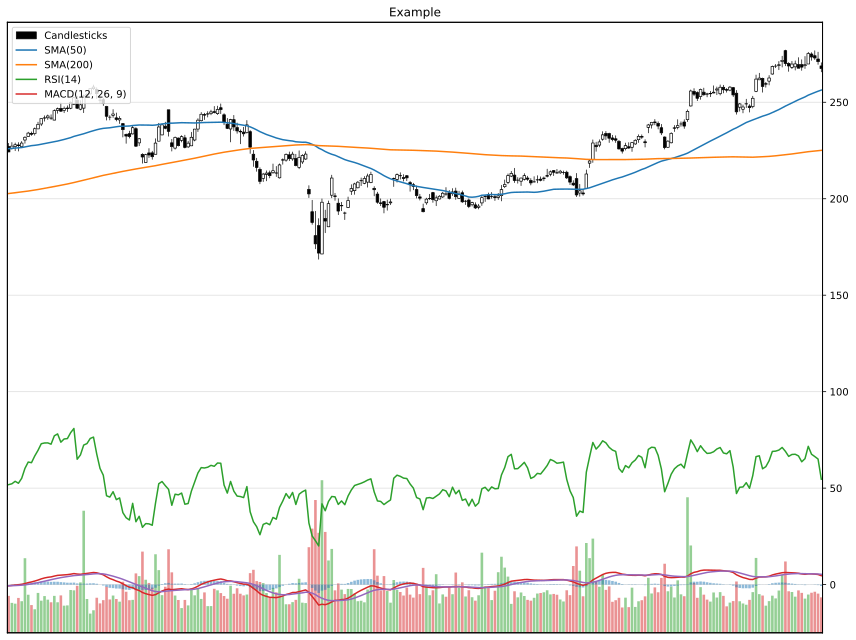

In [3]:
max_bars = 250

indicators = [
    Candlesticks(use_bars=False),
    SMA(50),
    SMA(200),
    Volume(),
    RSI(),
    MACD(),
]

chart = Chart(prices, title="Example", max_bars=max_bars)
chart.plot(indicators)

In [4]:
data = chart.render("svg")

print(data[:80])


b'<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "-//'


In [5]:
data = chart.render("png")

print(data[:80])

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\xb0\x00\x00\x03\x84\x08\x06\x00\x00\x00\xb1m\xc8\xfa\x00\x00\x00:tEXtSoftware\x00Matplotlib version3.10.8, http'


In [6]:
data = chart.render("jpg")

print(data[:80])

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00d\x00d\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\''
